# Grafo Vial de la Ciudad de México

Este notebook descarga la red vial de una zona de la CDMX usando **OSMnx** (OpenStreetMap),
la modela como un grafo dirigido con **NetworkX**, y la visualiza de múltiples formas.

Zona inicial: **Colonia Roma + Condesa** (manejable para prototipar, ~2k nodos)

## 1. Imports y configuración

In [1]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import folium
import numpy as np
import sklearn  # requerido por osmnx para nearest_nodes en grafos no proyectados
import warnings
warnings.filterwarnings('ignore')

print(f'OSMnx version: {ox.__version__}')
print(f'NetworkX version: {nx.__version__}')

/Users/rod/clases/mineria/movilidad/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


OSMnx version: 2.0.7
NetworkX version: 3.2.1


## 2. Descargar la red vial

Opciones de zona (descomenta la que quieras usar):

In [2]:
# Zona pequeña — Roma + Condesa (rápido, ideal para prototipo)
LUGAR = "Colonia Roma, Cuauhtémoc, Ciudad de México, Mexico"

# Zona mediana — Alcaldía Cuauhtémoc completa (~15k nodos)
# LUGAR = "Cuauhtémoc, Ciudad de México, Mexico"

# Ciudad completa (tarda varios minutos, ~150k nodos)
# LUGAR = "Ciudad de México, Mexico"

print(f'Descargando red vial de: {LUGAR}')
print('Esto puede tardar 10-30 segundos...')

# network_type='drive' = solo calles para vehículos
G = ox.graph_from_place(LUGAR, network_type='drive')

print(f'\n✓ Grafo descargado exitosamente')
print(f'  Nodos (intersecciones): {G.number_of_nodes():,}')
print(f'  Aristas (segmentos de calle): {G.number_of_edges():,}')
print(f'  Tipo de grafo: {type(G).__name__}')

Descargando red vial de: Colonia Roma, Cuauhtémoc, Ciudad de México, Mexico
Esto puede tardar 10-30 segundos...



✓ Grafo descargado exitosamente
  Nodos (intersecciones): 351
  Aristas (segmentos de calle): 626
  Tipo de grafo: MultiDiGraph


## 3. Explorar la estructura del grafo

Cada **nodo** es una intersección con coordenadas geográficas.  
Cada **arista** es un segmento de calle con atributos (longitud, velocidad, nombre, etc.)

In [3]:
# Ver atributos de un nodo
nodo_ejemplo = list(G.nodes())[0]
print('=== NODO (intersección) ===')
print(f'ID: {nodo_ejemplo}')
print(f'Datos: {G.nodes[nodo_ejemplo]}')

print()

# Ver atributos de una arista
arista_ejemplo = list(G.edges(data=True))[0]
print('=== ARISTA (segmento de calle) ===')
print(f'De nodo {arista_ejemplo[0]} → a nodo {arista_ejemplo[1]}')
print(f'Datos:')
for k, v in arista_ejemplo[2].items():
    print(f'  {k}: {v}')

=== NODO (intersección) ===
ID: 30341133
Datos: {'y': 19.4142446, 'x': -99.154672, 'street_count': 3}

=== ARISTA (segmento de calle) ===
De nodo 30341133 → a nodo 268312120
Datos:
  osmid: 569385799
  highway: primary
  lanes: 3
  maxspeed: 50
  name: Avenida Cuauhtémoc
  oneway: True
  ref: EJE 1 PTE
  reversed: False
  length: 36.625583916548116


In [4]:
# Estadísticas del grafo
stats = ox.basic_stats(G)
print('=== ESTADÍSTICAS DE LA RED VIAL ===')
claves_interes = [
    'n', 'm', 'k_avg', 'edge_length_total', 'edge_length_avg',
    'streets_per_node_avg', 'intersection_count'
]
for k in claves_interes:
    if k in stats:
        v = stats[k]
        if isinstance(v, float):
            print(f'  {k}: {v:.2f}')
        else:
            print(f'  {k}: {v:,}')

=== ESTADÍSTICAS DE LA RED VIAL ===
  n: 351
  m: 626
  k_avg: 3.57
  edge_length_total: 55964.69
  edge_length_avg: 89.40
  streets_per_node_avg: 3.59
  intersection_count: 342


## 4. Visualización estática con Matplotlib

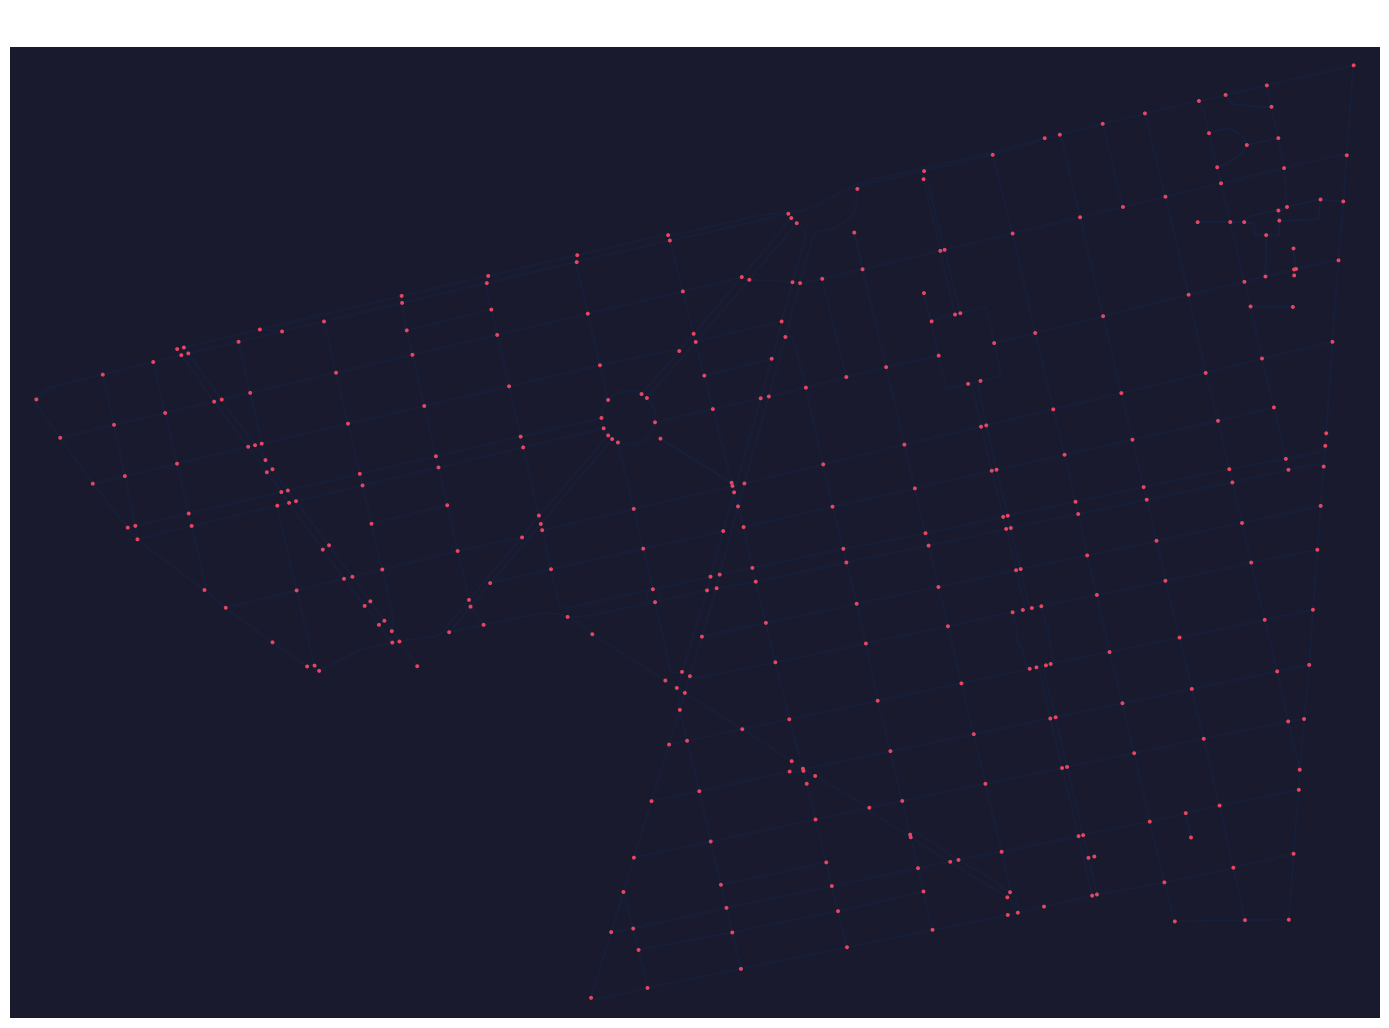

Imagen guardada: red_vial_cdmx.png


In [5]:
fig, ax = ox.plot_graph(
    G,
    figsize=(14, 14),
    bgcolor='#1a1a2e',
    node_color='#e94560',
    node_size=8,
    edge_color='#16213e',
    edge_linewidth=1.2,
    edge_alpha=0.8,
    show=False,
    close=False
)
ax.set_title('Red Vial — CDMX', color='white', fontsize=16, pad=15)
plt.tight_layout()
plt.savefig('red_vial_cdmx.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()
print('Imagen guardada: red_vial_cdmx.png')

## 5. Colorear aristas por velocidad máxima

Velocidad mínima en la red: 20.0 km/h
Velocidad máxima en la red: 50.0 km/h


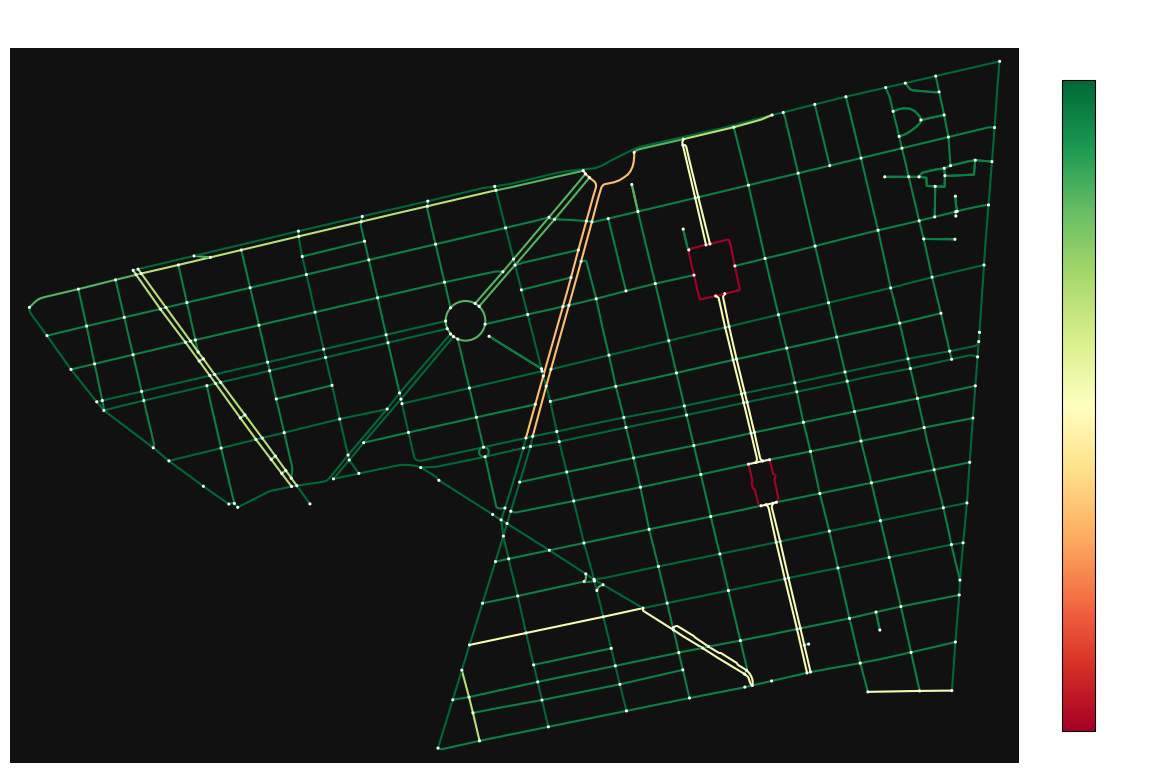

In [6]:
# Añadir velocidades donde faltan (OSMnx las infiere del tipo de vía)
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)

# Extraer velocidades por arista
velocidades = [d.get('speed_kph', 30) for u, v, d in G.edges(data=True)]
v_min, v_max = min(velocidades), max(velocidades)
print(f'Velocidad mínima en la red: {v_min} km/h')
print(f'Velocidad máxima en la red: {v_max} km/h')

# Normalizar y mapear a colores
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
cmap = cm.get_cmap('RdYlGn')  # Rojo = lento, Verde = rápido
edge_colors = [cmap(norm(v)) for v in velocidades]

fig, ax = ox.plot_graph(
    G,
    figsize=(14, 14),
    bgcolor='#111111',
    node_color='white',
    node_size=5,
    edge_color=edge_colors,
    edge_linewidth=1.5,
    show=False,
    close=False
)

# Colorbar
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Velocidad máxima (km/h)', color='white', fontsize=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Red Vial por Velocidad Máxima', color='white', fontsize=16, pad=15)
plt.savefig('red_vial_velocidades.png', dpi=150, bbox_inches='tight', facecolor='#111111')
plt.show()

## 6. Mapa interactivo con Folium

Un mapa HTML interactivo donde puedes hacer zoom y ver detalles de cada calle.

In [7]:
# Centroide del grafo
nodos_gdf, aristas_gdf = ox.graph_to_gdfs(G)
centro_lat = nodos_gdf['y'].mean()
centro_lon = nodos_gdf['x'].mean()

mapa = folium.Map(
    location=[centro_lat, centro_lon],
    zoom_start=15,
    tiles='CartoDB dark_matter'
)

# Dibujar aristas
for _, arista in aristas_gdf.iterrows():
    if arista.geometry is not None:
        coords = [(lat, lon) for lon, lat in arista.geometry.coords]
        velocidad = arista.get('speed_kph', 30)
        
        # Color según velocidad
        if velocidad >= 60:
            color = '#2ecc71'   # verde — vía rápida
        elif velocidad >= 40:
            color = '#f39c12'   # amarillo — avenida
        else:
            color = '#e74c3c'   # rojo — calle local
        
        tooltip = f"{arista.get('name', 'Sin nombre')} | {velocidad} km/h | {arista.get('length', 0):.0f}m"
        folium.PolyLine(
            coords,
            color=color,
            weight=2,
            opacity=0.8,
            tooltip=tooltip
        ).add_to(mapa)

# Dibujar nodos (intersecciones) — solo una muestra para no saturar
muestra_nodos = nodos_gdf.sample(min(200, len(nodos_gdf)))
for _, nodo in muestra_nodos.iterrows():
    folium.CircleMarker(
        location=[nodo['y'], nodo['x']],
        radius=3,
        color='white',
        fill=True,
        fill_opacity=0.8,
        tooltip=f"Nodo OSM: {nodo.name}"
    ).add_to(mapa)

# Leyenda
leyenda = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
     background: rgba(0,0,0,0.8); padding: 15px; border-radius: 8px;
     color: white; font-family: Arial; font-size: 13px;">
  <b>Velocidad máxima</b><br>
  <span style="color:#2ecc71">&#9644;</span> ≥ 60 km/h (vía rápida)<br>
  <span style="color:#f39c12">&#9644;</span> 40–59 km/h (avenida)<br>
  <span style="color:#e74c3c">&#9644;</span> &lt; 40 km/h (calle local)
</div>
'''
mapa.get_root().html.add_child(folium.Element(leyenda))

mapa.save('mapa_interactivo_cdmx.html')
print('Mapa guardado: mapa_interactivo_cdmx.html')
print('Ábrelo en tu navegador para explorarlo')
mapa

Mapa guardado: mapa_interactivo_cdmx.html
Ábrelo en tu navegador para explorarlo


## 7. Ruta más corta entre dos puntos (Dijkstra)

Encontramos el camino óptimo entre dos intersecciones usando el peso de **tiempo de viaje**.

In [8]:
# Usar el componente fuertemente conexo más grande
# (garantiza que siempre existe camino entre cualquier par de nodos)
G_scc = G.subgraph(
    max(nx.strongly_connected_components(G), key=len)
).copy()
print(f'Componente conexo principal: {G_scc.number_of_nodes()} nodos, {G_scc.number_of_edges()} aristas')

# Elegir dos nodos del grafo que estén lo más alejados posible
nodos_lista = list(G_scc.nodes())
np.random.seed(42)
nodo_origen = nodos_lista[0]
nodo_destino = nodos_lista[len(nodos_lista) // 2]

datos_origen = G_scc.nodes[nodo_origen]
datos_destino = G_scc.nodes[nodo_destino]
print(f'Origen:  lat={datos_origen["y"]:.4f}, lon={datos_origen["x"]:.4f}')
print(f'Destino: lat={datos_destino["y"]:.4f}, lon={datos_destino["x"]:.4f}')

# Calcular ruta más corta por tiempo de viaje
ruta = nx.shortest_path(G_scc, nodo_origen, nodo_destino, weight='travel_time')

longitud_total = sum(
    G_scc[ruta[i]][ruta[i+1]][0].get('length', 0)
    for i in range(len(ruta)-1)
)
tiempo_total = sum(
    G_scc[ruta[i]][ruta[i+1]][0].get('travel_time', 0)
    for i in range(len(ruta)-1)
)

print(f'\nRuta encontrada:')
print(f'  Nodos en la ruta: {len(ruta)}')
print(f'  Distancia total: {longitud_total:.0f} metros')
print(f'  Tiempo estimado: {tiempo_total:.0f} segundos ({tiempo_total/60:.1f} minutos)')

Componente conexo principal: 348 nodos, 621 aristas
Origen:  lat=19.4142, lon=-99.1547
Destino: lat=19.4132, lon=-99.1585

Ruta encontrada:
  Nodos en la ruta: 12
  Distancia total: 926 metros
  Tiempo estimado: 69 segundos (1.2 minutos)


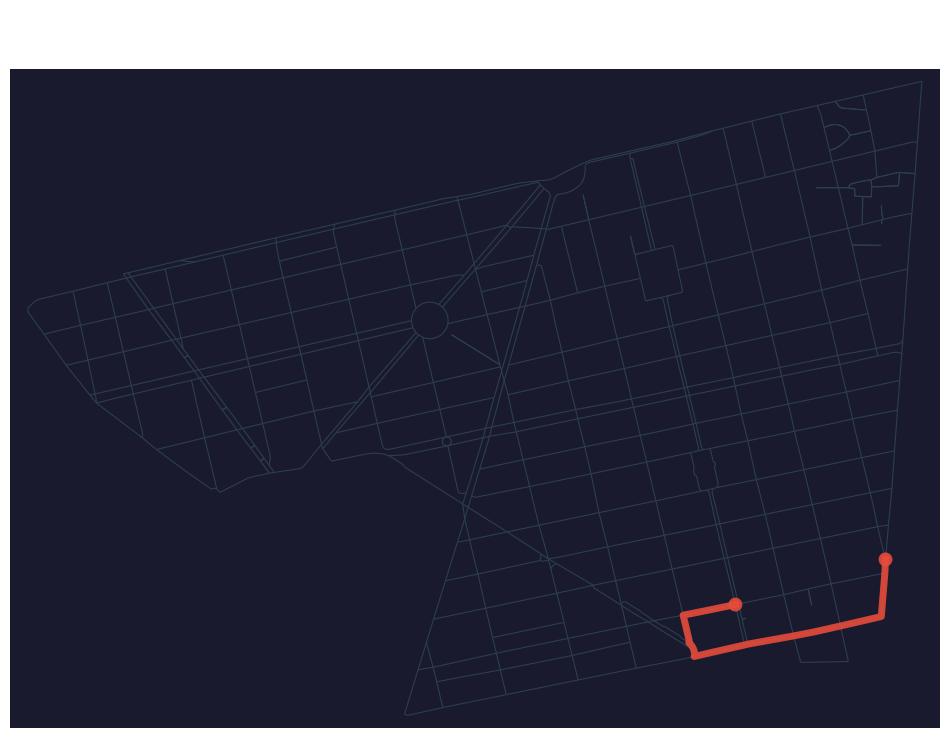

In [9]:
# Visualizar la ruta sobre el grafo
fig, ax = ox.plot_graph_route(
    G_scc,
    ruta,
    figsize=(12, 12),
    bgcolor='#1a1a2e',
    node_size=0,
    edge_color='#2c3e50',
    edge_linewidth=0.8,
    route_color='#e74c3c',
    route_linewidth=5,
    route_alpha=0.9,
    orig_dest_size=100,
    show=False,
    close=False
)

ax.set_title(
    f'Ruta más corta (por tiempo)\n'
    f'{longitud_total:.0f}m • {tiempo_total/60:.1f} min',
    color='white', fontsize=14, pad=15
)
plt.savefig('ruta_optima.png', dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 8. Análisis de centralidad

¿Qué intersecciones son las más **importantes** (más tráfico pasa por ellas)?  
Usamos **Betweenness Centrality** — qué tan seguido aparece un nodo en los caminos más cortos entre todos los pares.

In [10]:
print('Calculando centralidad de intermediación (puede tardar ~30s)...')

# Usar versión aproximada para grafos grandes (más rápido)
n_nodos = G.number_of_nodes()
muestra = min(500, n_nodos)  # Usar muestra para rapidez

centralidad = nx.betweenness_centrality(
    G,
    k=muestra,           # Muestra de nodos fuente
    weight='travel_time',
    normalized=True
)

# Asignar centralidad como atributo del nodo
nx.set_node_attributes(G, centralidad, 'betweenness')

# Top 10 intersecciones más críticas
top10 = sorted(centralidad.items(), key=lambda x: x[1], reverse=True)[:10]
print('\nTop 10 intersecciones más críticas:')
for i, (nodo, cent) in enumerate(top10, 1):
    datos = G.nodes[nodo]
    print(f'  {i:2d}. Nodo {nodo} | lat={datos["y"]:.4f}, lon={datos["x"]:.4f} | centralidad={cent:.4f}')

Calculando centralidad de intermediación (puede tardar ~30s)...



Top 10 intersecciones más críticas:
   1. Nodo 10272466741 | lat=19.4175, lon=-99.1642 | centralidad=0.2079
   2. Nodo 268384037 | lat=19.4174, lon=-99.1649 | centralidad=0.1581
   3. Nodo 2311012150 | lat=19.4184, lon=-99.1679 | centralidad=0.1553
   4. Nodo 268377490 | lat=19.4172, lon=-99.1659 | centralidad=0.1530
   5. Nodo 30879519 | lat=19.4181, lon=-99.1612 | centralidad=0.1503
   6. Nodo 2461266991 | lat=19.4174, lon=-99.1647 | centralidad=0.1491
   7. Nodo 268460565 | lat=19.4192, lon=-99.1696 | centralidad=0.1487
   8. Nodo 31241172 | lat=19.4183, lon=-99.1678 | centralidad=0.1486
   9. Nodo 268318087 | lat=19.4179, lon=-99.1626 | centralidad=0.1482
  10. Nodo 10925390052 | lat=19.4182, lon=-99.1678 | centralidad=0.1405


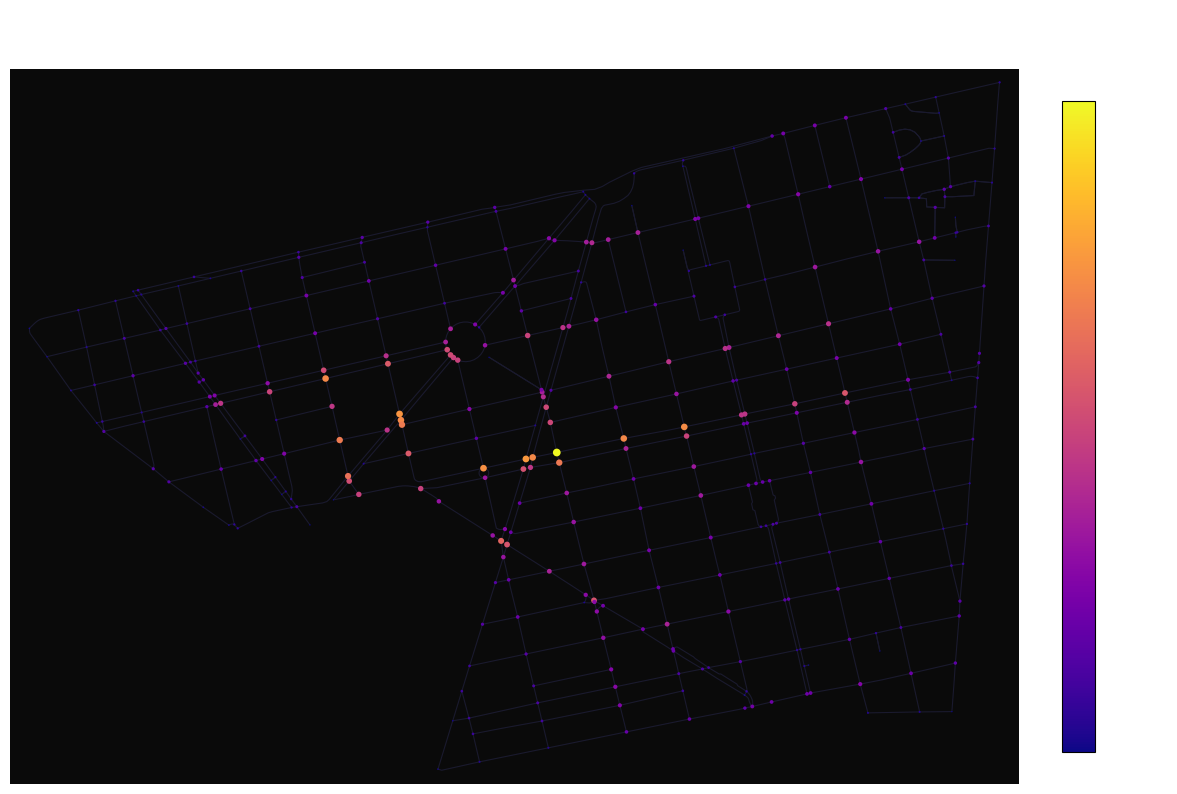


Estas intersecciones son candidatas principales para poner semáforos inteligentes!


In [11]:
# Visualizar centralidad — nodos más rojos/grandes = más críticos para el tráfico
valores_cent = [centralidad.get(n, 0) for n in G.nodes()]
v_max_cent = max(valores_cent) if valores_cent else 1

norm_cent = mcolors.Normalize(vmin=0, vmax=v_max_cent)
cmap_cent = cm.get_cmap('plasma')
node_colors = [cmap_cent(norm_cent(v)) for v in valores_cent]
node_sizes = [1 + 30 * norm_cent(v) for v in valores_cent]

fig, ax = ox.plot_graph(
    G,
    figsize=(14, 14),
    bgcolor='#0a0a0a',
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='#1a1a2e',
    edge_linewidth=0.8,
    show=False,
    close=False
)

sm2 = cm.ScalarMappable(cmap=cmap_cent, norm=norm_cent)
sm2.set_array([])
cbar2 = plt.colorbar(sm2, ax=ax, fraction=0.03, pad=0.04)
cbar2.set_label('Betweenness Centrality', color='white', fontsize=12)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

ax.set_title('Intersecciones críticas (Betweenness Centrality)\nMás brillante = más tráfico pasa por ahí',
             color='white', fontsize=14, pad=15)
plt.savefig('centralidad_cdmx.png', dpi=150, bbox_inches='tight', facecolor='#0a0a0a')
plt.show()
print('\nEstas intersecciones son candidatas principales para poner semáforos inteligentes!')

## 9. Guardar el grafo para reutilizarlo

Guardamos el grafo en formato GraphML para no tener que descargarlo cada vez.

In [12]:
ox.save_graphml(G, filepath='grafo_cdmx.graphml')
print('Grafo guardado en: grafo_cdmx.graphml')
print('Para cargarlo después:')
print("  G = ox.load_graphml('grafo_cdmx.graphml')")

Grafo guardado en: grafo_cdmx.graphml
Para cargarlo después:
  G = ox.load_graphml('grafo_cdmx.graphml')


## Siguientes pasos

Con este grafo como base, los siguientes notebooks construirán:

1. **`02_automata_celular.ipynb`** — Discretizar las aristas en celdas e implementar el modelo Nagel-Schreckenberg para simular vehículos moviéndose
2. **`03_semaforos.ipynb`** — Añadir semáforos en las intersecciones con fases y tiempos configurables
3. **`04_optimizacion_nsga2.ipynb`** — Optimización multiobjetivo con NSGA-II para encontrar la mejor configuración de semáforos
4. **`05_api_engine.ipynb`** — Exponer la simulación como API REST con FastAPI